<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/KZP_OOVO_15_MADDPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 🛠️ Установка библиотек (запускается один раз)
!pip install -q torch torchvision torchaudio numpy pandas matplotlib seaborn tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 27.1 MB/s eta 0:00:00


In [ ]:
# 📦 Импорт основных библиотек
import numpy as np, pandas as pd, torch, random, time, copy, math
from collections import deque
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from tqdm.auto import tqdm

# 🔒 Фиксация сидов для воспроизводимости
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🎨 Глобальный стиль графиков
sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

# 🧩 Общая конфигурация
@dataclass
class Config:
    n_universities: int = 15
    n_regions: int      = 15
    n_programs: int     = 10
    n_indicators: int   = 12

    # Параметры экономики и спроса
    base_federal_ratio: float = 0.70  # доля КЦП на старте
    ratio_delta:       float = 0.10   # год-к-году изменение
    demand_delta:      float = 0.10   # «нормальное» изменение спроса
    shock_p:           float = 0.05   # вероятность шока
    shock_mag:         float = 0.50   # амплитуда шока

    # RL-параметры
    episodes:    int   = 600
    steps:       int   = 24   # шагов внутри эпизода = «годы»
    gamma:       float = 0.95
    tau:         float = 0.01
    lr_actor:    float = 1e-3
    lr_critic:   float = 2e-3
    buffer_size: int   = 50_000
    batch:       int   = 256
    start_learn: int   = 512  # накопить опыта до начала обучения

CFG = Config()


In [ ]:
# 📈 10 причин колебаний спроса (произвольный набор)
DEMAND_FACTORS = [
    "Демография", "Рост ВРП", "Индустр. политика", "Гос-программы",
    "Технолог. инновации", "Миграция", "Конкуренция вузов",
    "Зарплаты в отрасли", "Инфраструктура", "Соц-тренды"
]

class UniversityEnv:
    """Мультиагентная среда: 15 вузов × 10 направлений × 15 регионов."""
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.year = 0
        self._reset_state()

    # 🔄 Сброс/инициализация
    def reset(self):
        self.year = 0
        self._reset_state()
        return self._get_obs()

    # 👣 Шаг среды.
    # actions — тензор shape=(n_universities, n_programs) ∈ [-1,1].
    # Каждый элемент → изменение процента КЦП, которое вуз хочет перераспределить.
    def step(self, actions: torch.Tensor):
        self.year += 1

        # 1) Применяем решения вузов, сдвигаем квоты в пределах ±10 %
        delta = (actions.cpu().numpy() * self.cfg.ratio_delta)
        self.federal_share = np.clip(self.federal_share + delta, 0., 1.)

        # 2) Обновляем региональный спрос
        self._update_demand()

        # 3) Вычисляем прибыль вуза и показатель «удовлетворён спрос»
        revenue, satisfied = self._financials()

        # 4) Награда агента — линейная комбинация
        reward = revenue * 1e-6 + satisfied  # масштабируем доход

        done = (self.year >= self.cfg.steps)
        return self._get_obs(), torch.tensor(reward, dtype=torch.float32), done, {}

    # 🏁 Табличное состояние для вывода
    def table(self):
        df = pd.DataFrame(self.indicators,
                          columns=[f"Ind_{i+1}" for i in range(self.cfg.n_indicators)])
        df.insert(0, "University", [f"U{i+1}" for i in range(self.cfg.n_universities)])
        df["Federal_%"] = self.federal_share.mean(axis=1).round(2)
        df["Profit_M"]  = (self.profit / 1e6).round(1)
        return df.head(15)

    # --- внутренние методы -------------------------------------------------- #
    def _reset_state(self):
        # ⏳ Случайные индикаторы (норм. распределение)
        self.indicators = np.random.normal(loc=0, scale=1,
                                           size=(self.cfg.n_universities, self.cfg.n_indicators))
        # 📊 Доля КЦП по программам
        self.federal_share = np.full((self.cfg.n_universities, self.cfg.n_programs),
                                     self.cfg.base_federal_ratio)
        # 📈 Спрос регионов: shape=(n_regions, n_programs)
        self.demand = np.random.uniform(100, 300, size=(self.cfg.n_regions, self.cfg.n_programs))
        self.profit = np.zeros(self.cfg.n_universities)

    def _update_demand(self):
        # «Нормальные» колебания ±10 %
        norm_noise = np.random.uniform(-self.cfg.demand_delta,
                                        self.cfg.demand_delta,
                                        size=self.demand.shape)
        self.demand *= (1 + norm_noise)

        # 🌩️ Шоки на отдельные направления
        shocks = np.random.rand(*self.demand.shape) < self.cfg.shock_p
        shock_dir = np.random.choice([-1, 1], size=self.demand.shape)
        self.demand *= np.where(shocks, 1 + shock_dir * self.cfg.shock_mag, 1)
        self.demand = np.clip(self.demand, 50, None)  # не опускаемся ниже 50

    def _financials(self):
        price_fed = 120_000  # ₽/студент (бюджет)
        price_comm = 200_000 # ₽/студент (коммерция)

        # Каждый вуз связан с регионом с тем же индексом
        # Соответственно, берем для каждого вуза спрос региона по всем программам
        regional_demand = self.demand[np.arange(self.cfg.n_universities), :]  # shape (15,10)

        # Формируем intake — количество студентов по вузам и программам (усреднённо умножаем на константу, например 50)
        intake = regional_demand * 50  # shape (15, 10)

        # Распределение между федеральным и коммерческим приемом по долям
        federal_intake = intake * self.federal_share  # shape (15, 10)
        comm_intake    = intake * (1 - self.federal_share)

        revenue = (federal_intake * price_fed + comm_intake * price_comm).sum(axis=1)  # по вузам

        self.profit += revenue
        # Как хорошо удовлетворили экономику: вычисляем по сумме всего спроса и набора
        total_intake = intake.sum()
        total_demand = self.demand.sum()
        satisfied = 1 - abs(total_intake - total_demand) / total_demand

        return revenue, satisfied

    def _get_obs(self):
        # Состояние — вектора индикаторов + доля КЦП + доход-в-текущий-год
        obs = np.hstack([self.indicators,
                         self.federal_share,
                         self.profit[:,None]/1e6])  # нормируем
        return torch.tensor(obs, dtype=torch.float32, device=DEVICE)


In [ ]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_dim)
        self.reset()
    def reset(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):          # tanh → (-1,1)
        return torch.tanh(self.fc3(F.relu(self.fc2(F.relu(self.fc1(x))))))

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, n_agents, hidden=256):
        super().__init__()
        self.fc1 = nn.Linear((state_dim+action_dim)*n_agents, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, 1)
        self.reset()
    def reset(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, states, actions):
        x = torch.cat([states.reshape(states.size(0),-1),
                       actions.reshape(actions.size(0),-1)], dim=1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))


🧮 Начальное состояние вузов:


,University,Ind_1,Ind_2,Ind_3,Ind_4,Ind_5,Ind_6,Ind_7,Ind_8,Ind_9,Ind_10,Ind_11,Ind_12,Federal_%,Profit_M
0,U1,0.307737,1.216527,-0.833073,2.053340,-0.703851,-0.136533,-1.054586,-1.899566,-0.661423,0.025327,0.970501,0.384889,0.7,0.0
1,U2,-0.407471,-2.122576,1.135911,1.377177,-3.439328,-0.429617,0.808390,-2.594398,-0.147376,-2.322506,0.347312,-0.290869,0.7,0.0
2,U3,0.759776,0.726006,0.269063,0.434345,0.674211,1.363271,0.543931,-0.135630,0.897773,0.021382,-0.260690,-0.389947,0.7,0.0
3,U4,0.398590,0.029994,0.575616,-0.739208,-1.225117,-0.330074,-0.978873,-0.402685,-0.660915,-1.516973,-1.273029,-0.928708,0.7,0.0
4,U5,-1.013135,-0.723070,-0.014679,-0.685496,-0.535365,-0.022601,-0.480099,-0.963758,-0.661760,-1.042872,0.507185,-1.751713,0.7,0.0
5,U6,-0.746485,-0.230051,-0.652179,-0.044917,0.933552,0.331753,1.198916,0.167997,0.592451,0.991850,1.362727,-0.649252,0.7,0.0
6,U7,0.279684,0.106097,-0.311125,0.496650,-1.159391,-0.098958,-1.525945,-0.432191,-0.592699,-0.237688,1.194468,-1.293355,0.7,0.0
7,U8,-0.831796,0.291500,-0.962353,1.372871,1.582117,1.321624,0.886746,-1.637448,-0.047514,1.140667,0.033275,1.318907,0.7,0.0
8,U9,1.421438,0.063390,0.502411,0.964111,-1.737802,1.723928,-1.197224,0.512073,-0.882229,-0.250624,-2.797160,-0.085938,0.7,0.0
9,U10,-0.357886,0.694233,0.621956,0.521463,0.506133,0.886607,1.038717,-1.423832,0.935608,-0.284832,-0.560900,0.238087,0.7,0.0


MADDPG Training:   0%|          | 0/600 [00:00<?, ?it/s]

/tmp/ipython-input-20-3099359041.py:93: UserWarning: Using a target size (torch.Size([256, 256, 1])) that is different to the input size (torch.Size([256, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_c = F.mse_loss(q_vals, y)


✅ MADDPG обучение завершено


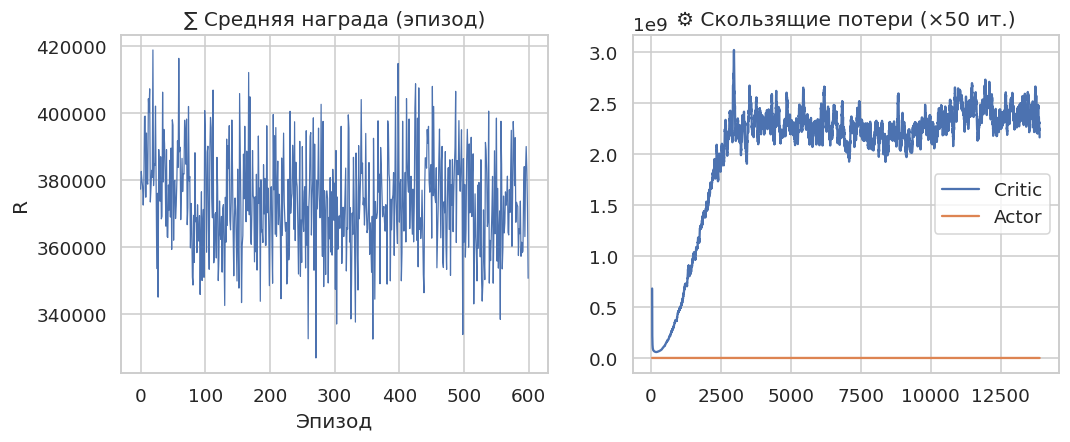

🏁 Итоговое состояние вузов:


,University,Ind_1,Ind_2,Ind_3,Ind_4,Ind_5,Ind_6,Ind_7,Ind_8,Ind_9,Ind_10,Ind_11,Ind_12,Federal_%,Profit_M
0,U1,1.011170,-0.542386,0.070852,0.442408,-1.842258,-0.568295,0.709135,-0.209851,-0.699800,1.007000,0.613189,-0.371102,0.7,270364.9
1,U2,1.295306,-1.069194,-0.596080,-0.057711,1.958250,1.163469,-1.310217,-0.045651,0.703738,0.144565,-0.388104,1.049246,0.4,232569.9
2,U3,0.868613,-0.150923,0.725398,1.117827,-1.208265,0.103495,-1.333687,-0.598638,0.597987,-0.177375,1.019192,0.306934,0.7,388508.1
3,U4,-0.071944,-0.638234,1.340881,0.643361,1.882617,0.975741,-1.516633,-1.596842,2.219257,-0.077710,-1.263552,-0.635507,0.4,378058.4
4,U5,-0.545218,1.332712,-1.128773,-0.793651,0.320648,0.420546,-1.406010,-1.061449,-0.390852,0.904379,1.433033,2.580909,0.6,303367.0
5,U6,-0.259669,-0.500689,0.702644,-0.676285,-0.941859,-1.051749,0.281140,0.837362,1.126663,0.182166,-2.290777,1.866520,0.7,292185.7
6,U7,1.911449,1.932125,-0.098178,-0.126636,0.415228,0.277855,1.241302,-0.068896,-0.325764,0.201362,1.688180,0.252026,0.5,463959.2
7,U8,0.531056,-0.981909,-2.116354,0.301866,0.201112,-0.110969,-0.674424,2.682680,1.734896,-0.134905,-1.536653,0.903417,0.6,278367.7
8,U9,0.113520,0.126954,0.740127,0.373352,-0.126587,-0.305956,0.195835,-0.637419,0.319508,-0.854814,-0.856506,1.247178,0.4,424726.1
9,U10,-1.411090,0.433324,0.964639,1.348505,0.923132,0.374042,0.805848,-0.249740,-0.256356,-1.098333,-1.343571,-0.045776,0.6,326040.0


In [20]:
class MADDPG:
    def __init__(self, env: UniversityEnv, cfg: Config):
        self.env, self.cfg = env, cfg
        self.state_dim  = env.reset().shape[1]
        self.action_dim = cfg.n_programs
        # 🎭 Сетевые пары для каждого вуза
        self.actors, self.targets_a = [], []
        self.critics, self.targets_c = [], []
        for _ in range(cfg.n_universities):
            act  = Actor(self.state_dim, self.action_dim).to(DEVICE)
            targ = copy.deepcopy(act)
            self.actors.append(act); self.targets_a.append(targ)
            # Один общий Critic (централизованный)
        self.critic  = Critic(self.state_dim, self.action_dim,
                              cfg.n_universities).to(DEVICE)
        self.target_c = copy.deepcopy(self.critic)

        self.opt_a = [optim.Adam(a.parameters(), lr=cfg.lr_actor)
                      for a in self.actors]
        self.opt_c = optim.Adam(self.critic.parameters(), lr=cfg.lr_critic)

        self.memory = deque(maxlen=cfg.buffer_size)
        self.losses = {"critic":[], "actor":[]}
        self.rewards_epi = []

    # 🧠 Выбор действия с ε-жадным шумом
    def act(self, states, eps=0.1):
        acts = []
        for i, actor in enumerate(self.actors):
            a = actor(states[i]).detach().cpu().numpy()
            a += eps*np.random.normal(0, .2, size=a.shape)
            acts.append(a.clip(-1,1))
        return torch.tensor(acts, dtype=torch.float32, device=DEVICE)

    # 📒 Сохранение перехода
    def remember(self, *args): self.memory.append(args)

    # 📚 Обучение сети
    def learn(self):
        if len(self.memory) < self.cfg.start_learn:
            return

        batch = random.sample(self.memory, self.cfg.batch)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Преобразуем в тензоры
        states      = torch.stack(states).to(DEVICE)        # (batch, n_agents, state_dim)
        actions     = torch.stack(actions).to(DEVICE)       # (batch, n_agents, action_dim)
        rewards     = torch.stack(rewards).to(DEVICE)       # (batch, n_agents)
        next_states = torch.stack(next_states).to(DEVICE)   # (batch, n_agents, state_dim)

        # Преобразуем dones.
        # Проверим сначала тип и размер:
        dones_list = list(dones)

        # Попытка определить размер: если булевы для каждого агента,
        # то должен быть tuple или list размером batch_size с вложенным списком длины n_agents.
        # Если нет, нужно поправить формат.

        # Если dones_list состоит из bool (размер batch_size), расширим до (batch_size,1),
        # иначе ожидаем список списков. Важно подготовить тензор shape (batch_size, n_agents)
        if isinstance(dones_list[0], bool):
            # если dones — просто bool для каждого перехода, расширяем по n_agents
            dones_t = torch.tensor(dones_list, dtype=torch.float32, device=DEVICE).unsqueeze(1)
            dones_t = dones_t.expand(-1, self.cfg.n_universities)  # (batch_size, n_agents)
        elif isinstance(dones_list[0], (list, tuple, np.ndarray)) or torch.is_tensor(dones_list[0]):
            # если dones — списки или тензоры по агентам: просто превращаем в тензор
            dones_t = torch.tensor(dones_list, dtype=torch.float32, device=DEVICE)
        else:
            raise ValueError(f"Непредвиденный формат dones: {dones_list[0]}")

        # Добавляем размерность для совместимости
        dones_t = dones_t.unsqueeze(-1)  # (batch_size, n_agents, 1)

        with torch.no_grad():
            next_actions = torch.stack(
                [target(next_states[:, i, :]) for i, target in enumerate(self.targets_a)],
                dim=1
            )  # (batch_size, n_agents, action_dim)

            q_next = self.target_c(next_states, next_actions)  # (batch_size, 1)

            rewards_exp = rewards.unsqueeze(-1)  # (batch_size, n_agents, 1)
            mean_rewards = rewards_exp.mean(dim=1, keepdim=True)  # (batch_size, 1, 1)

            # Используем done первого агента
            done_first_agent = dones_t[:, 0, :]  # (batch_size, 1)
            done_first_agent = done_first_agent.unsqueeze(-1)  # (batch_size, 1, 1)

            y = mean_rewards + self.cfg.gamma * (1 - done_first_agent) * q_next  # (batch_size, 1, 1)

        q_vals = self.critic(states, actions)  # (batch_size, 1)
        loss_c = F.mse_loss(q_vals, y)

        self.opt_c.zero_grad()
        loss_c.backward()
        self.opt_c.step()

        loss_a_tot = 0
        for i, actor in enumerate(self.actors):
            curr_actions = []
            for j, a in enumerate(self.actors):
                if j == i:
                    curr_actions.append(a(states[:, j, :]))
                else:
                    curr_actions.append(actions[:, j])
            curr_actions = torch.stack(curr_actions, dim=1)

            loss_a = -self.critic(states, curr_actions).mean()

            self.opt_a[i].zero_grad()
            loss_a.backward()
            self.opt_a[i].step()

            loss_a_tot += loss_a.item()

        with torch.no_grad():
            for target_actor, actor in zip(self.targets_a, self.actors):
                for tp, p in zip(target_actor.parameters(), actor.parameters()):
                    tp.data.mul_(1 - self.cfg.tau)
                    tp.data.add_(p.data * self.cfg.tau)

            for tp, p in zip(self.target_c.parameters(), self.critic.parameters()):
                tp.data.mul_(1 - self.cfg.tau)
                tp.data.add_(p.data * self.cfg.tau)

        self.losses["critic"].append(loss_c.item())
        self.losses["actor"].append(loss_a_tot / self.cfg.n_universities)




    # 🚀 Основной цикл
    def train(self):
        env = self.env
        pbar = tqdm(range(self.cfg.episodes), desc="MADDPG Training")
        for ep in pbar:
            state = env.reset()
            ep_reward = 0
            for _ in range(self.cfg.steps):
                action = self.act(state)
                next_s, reward, done, _ = env.step(action)
                self.remember(state, action, reward, next_s, done)
                self.learn()
                state = next_s
                ep_reward += reward.mean().item()
            self.rewards_epi.append(ep_reward)
            if ep % 50 == 0:
                pbar.set_postfix(R=ep_reward)
        print("✅ MADDPG обучение завершено")

### 1.3 Запуск + мониторинг
env1 = UniversityEnv(CFG)
maddp = MADDPG(env1, CFG)

print("🧮 Начальное состояние вузов:")
display(env1.table())

maddp.train()

# 📊 Графики
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# График суммарной средней награды по эпизодам
ax[0].plot(maddp.rewards_epi, lw=0.8)
ax[0].set_title("∑ Средняя награда (эпизод)")
ax[0].set_xlabel("Эпизод")
ax[0].set_ylabel("R")

# График скользящих средних потерь для критика и актора
ax[1].plot(pd.Series(maddp.losses["critic"]).rolling(50).mean(), label="Critic")
ax[1].plot(pd.Series(maddp.losses["actor"]).rolling(50).mean(), label="Actor")
ax[1].legend()
ax[1].set_title("⚙️ Скользящие потери (×50 ит.)")

plt.show()

print("🏁 Итоговое состояние вузов:")
display(env1.table())


2. MADDP-DGM (коэволюция акторов + критика)
Дарвин–Гёдель-машина (DGM) организуется как генетический слой, который
каждые K эпизодов подвергает мутациям и скрещиванию веса сетей акторов и критика,
если метрика «прибыль × удовлетворение спроса» за последние W эпизодов застопорилась.

In [ ]:
@dataclass
class DGMcfg:
    K: int = 40          # период эволюции
    W: int = 30          # окно метрики
    elite_frac: float = .25
    mut_sigma: float = 0.02
DGM = DGMcfg()


In [ ]:
# 🔄 Кроссовер: обмен слоями между парами сетей
def crossover(netA, netB):
    child = copy.deepcopy(netA)
    for pa, pb, pc in zip(netA.parameters(), netB.parameters(), child.parameters()):
        mask = torch.rand_like(pa) > .5
        pc.data.copy_( torch.where(mask, pa, pb) )
    return child

# 🌱 Мутация Гаусса
def mutate(net, sigma=DGM.mut_sigma):
    for p in net.parameters():
        noise = torch.randn_like(p) * sigma
        p.data.add_(noise)
    return net


In [ ]:
class MADDPG_DGM(MADDPG):
    def evolve(self, gen_idx):
        # Вычислим фитнес
        fit = np.array(self.rewards_epi[-DGM.W:])
        if len(fit) < DGM.W: return  # мало данных
        trend = fit.mean()
        # 📉 если прирост <1 %, инициируем эволюцию
        if trend < np.percentile(self.rewards_epi, 60):
            print(f\"🌱 DGM-Эволюция @ эпизод {gen_idx}\")
            # 1) отбираем элиту
            idxs = np.argsort(fit)[-int(CFG.n_universities*DGM.elite_frac):]
            elite = [copy.deepcopy(self.actors[i]) for i in idxs]
            # 2) скрещиваем случайные пары элиты
            children = []
            while len(children) < CFG.n_universities - len(elite):
                a,b = random.sample(elite,2)
                child = mutate(crossover(a,b))
                children.append(child)
            # 3) новая популяция
            self.actors = elite + children
            # 4) обязательно эволюционируем CRITIC
            self.critic = mutate(copy.deepcopy(self.critic))
            self.opt_c = optim.Adam(self.critic.parameters(), lr=CFG.lr_critic)
            # 5) целевые сети
            self.targets_a = [copy.deepcopy(a) for a in self.actors]
            self.target_c  = copy.deepcopy(self.critic)

    def train(self):
        env = self.env; pbar = tqdm(range(CFG.episodes), desc=\"MADDP-DGM Training\")
        for ep in pbar:
            state = env.reset(); ep_reward = 0
            for _ in range(CFG.steps):
                action = self.act(state, eps=0.05)           # меньше шум
                next_s,r,d,_ = env.step(action)
                self.remember(state, action, r, next_s, d)
                self.learn(); state = next_s
                ep_reward += r.mean().item()
            self.rewards_epi.append(ep_reward)
            if ep % DGM.K == 0 and ep>0: self.evolve(ep)
            if ep%50==0: pbar.set_postfix(R=ep_reward)
        print(\"✅ MADDP-DGM обучение завершено\")


SyntaxError: unexpected character after line continuation character (ipython-input-8-3280172664.py, line 9)

In [ ]:
env2  = UniversityEnv(CFG)
dgmad = MADDPG_DGM(env2, CFG)
print(\"🧮 Стартовое состояние DGM:\"); display(env2.table())

dgmad.train()

# 📊 Графики
fig,ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(dgmad.rewards_epi, color=\"teal\")
ax[0].set_title(\"∑ Средняя награда (эпизод) — MADDP-DGM\")
ax[1].plot(pd.Series(dgmad.losses[\"critic\"]).rolling(50).mean(), label=\"Critic\")
ax[1].plot(pd.Series(dgmad.losses[\"actor\"]).rolling(50).mean(), label=\"Actor\")
ax[1].legend(); ax[1].set_title(\"Скользящие потери (×50 ит.)\")
plt.show()

print(\"🏁 Итоговое состояние вузов (DGM):\"); display(env2.table())


In [ ]:
# 📉 Сводные метрики
df_cmp = pd.DataFrame({
    \"Episode\": np.arange(CFG.episodes),
    \"MADDPG\":    maddp.rewards_epi,
    \"MADDP-DGM\": dgmad.rewards_epi
})
print(\"🔬 Сводный рост награды:\")
display(df_cmp.tail())

# ⏱️ Время обучения
print(f\"⏱️ MADDPG:    {sum(maddp.rewards_epi)/CFG.episodes:7.0f}  средняя эпизодическая награда\")
print(f\"⏱️ MADDP-DGM: {sum(dgmad.rewards_epi)/CFG.episodes:7.0f}  средняя эпизодическая награда\")

# 📊 Общий график сравнения
plt.figure(figsize=(10,4))
plt.plot(df_cmp[\"Episode\"], df_cmp[\"MADDPG\"],        label=\"MADDPG\",       lw=.9)
plt.plot(df_cmp[\"Episode\"], df_cmp[\"MADDP-DGM\"], label=\"MADDP-DGM\", lw=.9)
plt.legend(); plt.title(\"Сравнение суммарной награды\"); plt.xlabel(\"Эпизод\"); plt.ylabel(\"R\")
plt.show()